In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional,GRU, Dense, Dropout

In [2]:
df = pd.read_csv("Dataset.csv", sep=",")
print(df.shape)
df.head()


(1048575, 44)


,S.No.,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [3]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Identify feature columns
feature_cols = [col for col in df.columns if col not in ["SepsisLabel", "Patient_ID"]]

# Forward-fill within each patient, then replace remaining NaN with 0
df = (
    df.sort_values(["Patient_ID", "Hour"])
      .groupby("Patient_ID", group_keys=False)[feature_cols]
      .ffill()
      .fillna(0)
)

# Add back patient_id + label
df["Patient_ID"] = pd.read_csv("Dataset.csv")["Patient_ID"]
df["SepsisLabel"] = pd.read_csv("Dataset.csv")["SepsisLabel"]

# ==========================
# STEP 4: Normalize features
# ==========================
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ==========================
# STEP 5: Create sequences per patient
# ==========================
def create_sequences(patient_df, seq_len=12):
    sequences, labels = [], []
    features = patient_df[feature_cols].values
    targets = patient_df["SepsisLabel"].values
    
    for i in range(len(features) - seq_len):
        sequences.append(features[i:i+seq_len])
        labels.append(targets[i+seq_len])
    return np.array(sequences), np.array(labels)

X_seq, y_seq = [], []
for pid, group in df.groupby("Patient_ID"):
    seqs, lbls = create_sequences(group, seq_len=12)  # 12-hour window
    if len(seqs) > 0:
        X_seq.append(seqs)
        y_seq.append(lbls)

X_seq = np.vstack(X_seq)
y_seq = np.hstack(y_seq)

print("Final X shape:", X_seq.shape)  # (samples, timesteps, features)
print("Final y shape:", y_seq.shape)  # (samples,)

# ==========================
# STEP 6: Train/Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

# ==========================
# STEP 7: Build GRU Model
# ==========================
model = Sequential([
    Bidirectional(GRU(64, return_sequences=True), 
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    Bidirectional(GRU(32)),   # returns last output by default
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC()])
model.summary()

# ==========================
# STEP 8: Train Model
# ==========================
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=1
)

# ==========================
# STEP 9: Evaluate
# ==========================
loss, acc, auc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}, AUC: {auc:.4f}")


Final X shape: (725054, 12, 42)
Final y shape: (725054,)


c:\Users\lewin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 12, 128)        │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,641 (283.75 KB)

 Trainable params: 72,641 (283.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 89s 12ms/step - accuracy: 0.9747 - auc: 0.7725 - loss: 0.0991 - val_accuracy: 0.9785 - val_auc: 0.8535 - val_loss: 0.0820
Epoch 2/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - accuracy: 0.9786 - auc: 0.8555 - loss: 0.0811 - val_accuracy: 0.9789 - val_auc: 0.8967 - val_loss: 0.0729
Epoch 3/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 84s 12ms/step - accuracy: 0.9795 - auc: 0.9076 - loss: 0.0690 - val_accuracy: 0.9805 - val_auc: 0.9247 - val_loss: 0.0630
Epoch 4/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 111s 15ms/step - accuracy: 0.9818 - auc: 0.9382 - loss: 0.0567 - val_accuracy: 0.9824 - val_auc: 0.9334 - val_loss: 0.0557
Epoch 5/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 94s 13ms/step - accuracy: 0.9843 - auc: 0.9572 - loss: 0.0474 - val_accuracy: 0.9842 - val_auc: 0.9553 - val_loss: 0.0469
Epoch 6/10
7251/7251 ━━━━━━━━━━━━━━━━━━━━ 182s 19ms/step - accuracy: 0.9854 - auc: 0.9684 - loss: 0.0421 - val_accuracy: 0.9842 - val_auc: 0.9637 - val_loss: 0.0440
Epoch 7/10
725

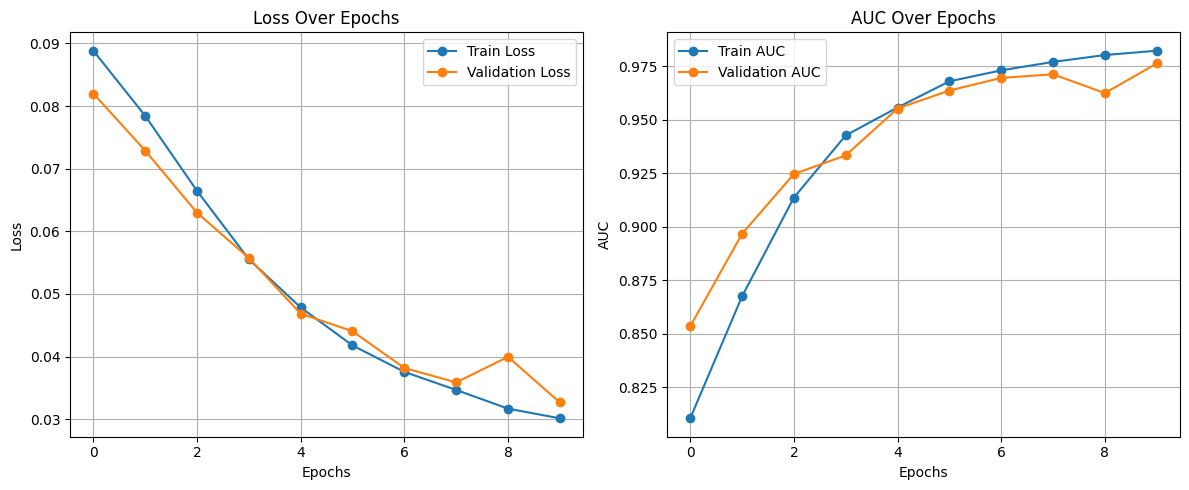

In [4]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training & validation AUC
plt.subplot(1,2,2)
plt.plot(history.history['auc'], label='Train AUC', marker='o')
plt.plot(history.history['val_auc'], label='Validation AUC', marker='o')
plt.title('AUC Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]
train_auc = history.history['auc'][-1]
val_auc = history.history['val_auc'][-1]

print(f"Final Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
print(f"Final Training AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")

Final Training Loss: 0.0301, Validation Loss: 0.0327
Final Training AUC: 0.9823, Validation AUC: 0.9764


In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# y_test = true labels, y_pred = model predictions (threshold 0.5 for binary)
y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Detailed report
print(classification_report(y_test, y_pred))

4532/4532 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
Confusion Matrix:
 [[141232    671]
 [  1084   2024]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    141903
           1       0.75      0.65      0.70      3108

    accuracy                           0.99    145011
   macro avg       0.87      0.82      0.85    145011
weighted avg       0.99      0.99      0.99    145011



4532/4532 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


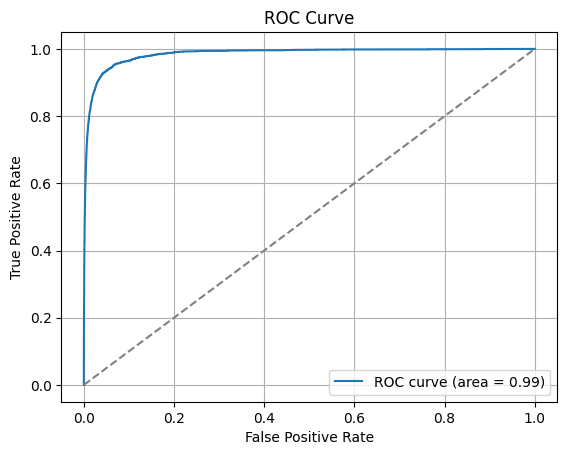

In [7]:
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Suppose X_train, y_train are your current training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train_final)}, Validation samples: {len(X_val)}")

Training samples: 464034, Validation samples: 116009


In [9]:
X = df.drop(columns=['SepsisLabel', 'Patient_ID']).values
y = df['SepsisLabel'].values

print("X shape:", X.shape)
print("y shape:", y.shape)

# Now split into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

X shape: (1048575, 42)
y shape: (1048575,)
Train: (838860, 42) (838860,)
Validation: (209715, 42) (209715,)


In [10]:
timesteps = 12   # sequence length
features = 41

# Convert flat data into sequences
X_seq = []
y_seq = []

for pid, group in df.groupby("Patient_ID"):
    values = group.drop(columns=['SepsisLabel', 'Patient_ID']).values
    labels = group['SepsisLabel'].values
    
    for i in range(len(values) - timesteps + 1):
        X_seq.append(values[i:i+timesteps])
        y_seq.append(labels[i+timesteps-1])  # label = last timestep

X = np.array(X_seq)
y = np.array(y_seq)

print("Final X shape:", X.shape)  # (samples, timesteps, features)
print("Final y shape:", y.shape)


Final X shape: (751507, 12, 42)
Final y shape: (751507,)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (601205, 12, 42) (601205,)
Validation: (150302, 12, 42) (150302,)


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',   # or 'val_auc' if you want
    patience=3,           # stop if no improvement for 3 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,            # large max
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 76s 16ms/step - accuracy: 0.9899 - auc: 0.9817 - loss: 0.0289 - val_accuracy: 0.9916 - val_auc: 0.9872 - val_loss: 0.0236
Epoch 2/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 76s 16ms/step - accuracy: 0.9909 - auc: 0.9866 - loss: 0.0255 - val_accuracy: 0.9918 - val_auc: 0.9897 - val_loss: 0.0227
Epoch 3/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 76s 16ms/step - accuracy: 0.9916 - auc: 0.9884 - loss: 0.0232 - val_accuracy: 0.9913 - val_auc: 0.9875 - val_loss: 0.0241
Epoch 4/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.9919 - auc: 0.9889 - loss: 0.0222 - val_accuracy: 0.9928 - val_auc: 0.9891 - val_loss: 0.0210
Epoch 5/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.9923 - auc: 0.9898 - loss: 0.0212 - val_accuracy: 0.9930 - val_auc: 0.9897 - val_loss: 0.0195
Epoch 6/100
4697/4697 ━━━━━━━━━━━━━━━━━━━━ 54s 12ms/step - accuracy: 0.9930 - auc: 0.9901 - loss: 0.0195 - val_accuracy: 0.9930 - val_auc: 0.9860 - val_loss: 0.0202
Epoch 7/10

In [13]:
model.save("bigru_sepsis_best_shap.h5")

In [14]:
val_loss, val_acc, val_auc = model.evaluate(X_val, y_val)
print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}, AUC: {val_auc:.4f}")

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9929 - auc: 0.9892 - loss: 0.0196
Validation Loss: 0.0195, Accuracy: 0.9930, AUC: 0.9897


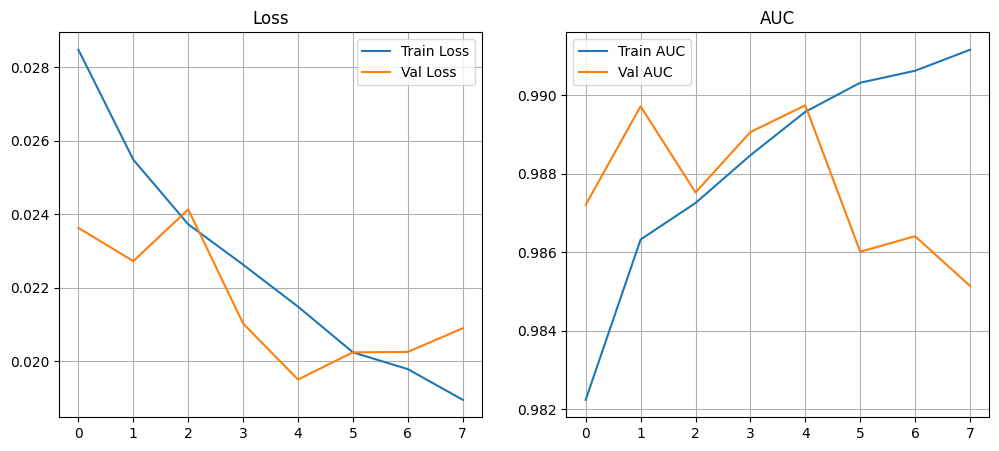

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend(); plt.grid(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['auc'], label="Train AUC")
plt.plot(history.history['val_auc'], label="Val AUC")
plt.legend(); plt.grid(); plt.title("AUC")

plt.show()

In [16]:
y_pred = (model.predict(X_val) > 0.5).astype(int)

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [17]:
from sklearn.metrics import classification_report

y_val_pred = (model.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, y_val_pred))

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    147118
           1       0.85      0.82      0.83      3184

    accuracy                           0.99    150302
   macro avg       0.92      0.91      0.92    150302
weighted avg       0.99      0.99      0.99    150302



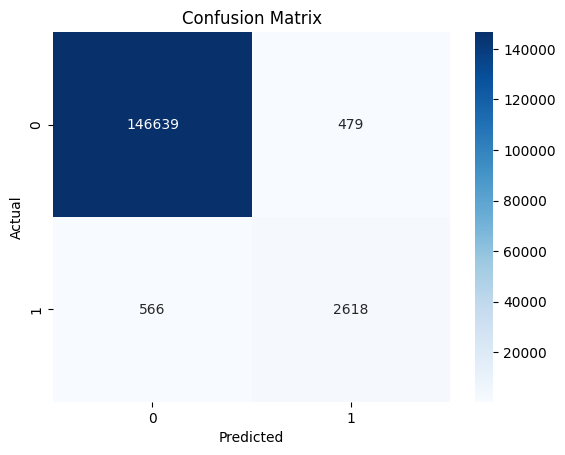

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

4697/4697 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Validation AUC: 0.9951


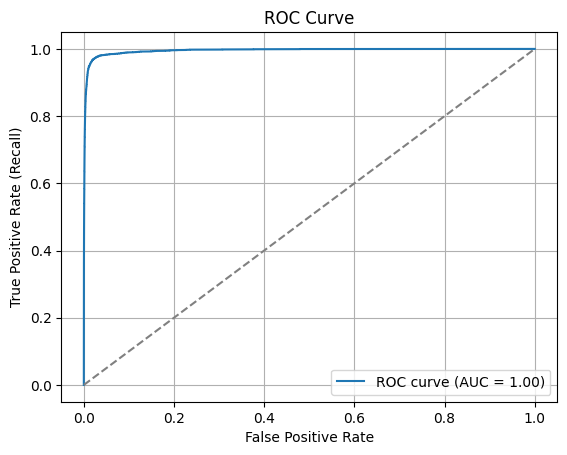

Best threshold: 0.033

Classification report at best threshold:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    147118
           1       0.51      0.97      0.67      3184

    accuracy                           0.98    150302
   macro avg       0.76      0.97      0.83    150302
weighted avg       0.99      0.98      0.98    150302



In [19]:
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predicted probabilities for validation set
y_val_prob = model.predict(X_val)  # values between 0 and 1

# 2. Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)
print(f"Validation AUC: {roc_auc:.4f}")

# 3. Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# 4. Find the best threshold
# Method: maximize (Recall - False Positive Rate) → Youden's J statistic
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]
print(f"Best threshold: {best_threshold:.3f}")

# 5. Evaluate metrics at this threshold
y_val_pred_best = (y_val_prob >= best_threshold).astype(int)
print("\nClassification report at best threshold:")
print(classification_report(y_val, y_val_pred_best))

In [20]:
model.save("sepsis_bigru_model_shap.h5")

# Save the best threshold
import json
best_threshold = 0.013
with open("best_threshold.json", "w") as f:
    json.dump({"threshold": best_threshold}, f)

In [21]:
from tensorflow.keras.models import load_model
import json

# Load model
model = load_model("sepsis_bigru_model_shap.h5")

# Load threshold
with open("best_threshold.json", "r") as f:
    best_threshold = json.load(f)["threshold"]

In [22]:
print("Loaded threshold:", best_threshold)


Loaded threshold: 0.013


In [23]:
X_test_preprocessed = X_test  # replace with actual preprocessed test data
y_test_true = y_test  
y_prob = model.predict(X_test_preprocessed)

# Apply threshold
y_pred = (y_prob >= best_threshold).astype(int)

4532/4532 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test_true, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test_true, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    141903
           1       0.39      0.98      0.56      3108

    accuracy                           0.97    145011
   macro avg       0.69      0.97      0.77    145011
weighted avg       0.99      0.97      0.97    145011

Confusion Matrix:
[[137101   4802]
 [    61   3047]]


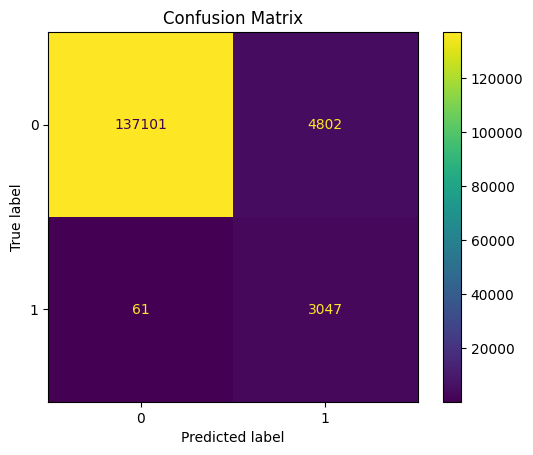

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


In [39]:
# Force model to build input/output tensors
_ = model.predict(X_train[:1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [26]:
from tensorflow.keras.models import load_model
import numpy as np
import json

# --- Load model & threshold ---
model = load_model("sepsis_bigru_model_shap.h5")
with open("best_threshold.json", "r") as f:
    best_threshold = json.load(f)["threshold"]
print("Using threshold:", best_threshold)

# --- Your sequence here (12 x 41) ---
new_patient_sequence = [
    [80, 98, 36.7, 120, 80, 93, 18, 35, 1, 24, 0.21, 7.40, 40, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [82, 97, 36.8, 118, 78, 92, 19, 36, 0, 23, 0.22, 7.39, 42, 97, 24, 1, 11, 13, 0.5, 2.1, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 97, 36.7, 119, 79, 92, 18, 35, 0, 23, 0.21, 7.40, 41, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [79, 96, 36.6, 117, 77, 91, 17, 34, 0, 23, 0.21, 7.39, 39, 96, 23, 1, 9, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [78, 97, 36.7, 118, 78, 92, 18, 35, 0, 23, 0.21, 7.39, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 98, 36.8, 119, 79, 93, 18, 35, 1, 24, 0.21, 7.40, 41, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.39, 42, 97, 24, 1, 11, 13, 0.5, 2.1, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [82, 96, 36.6, 117, 77, 91, 17, 35, 0, 23, 0.21, 7.39, 41, 96, 23, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.40, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [79, 96, 36.6, 117, 77, 91, 17, 35, 0, 23, 0.21, 7.39, 39, 96, 23, 1, 9, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [80, 97, 36.7, 118, 78, 92, 18, 34, 0, 23, 0.21, 7.40, 40, 97, 24, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [81, 98, 36.8, 119, 79, 93, 18, 35, 1, 24, 0.21, 7.40, 41, 98, 25, 1, 10, 12, 0.5, 2, 0.1, 0, 0.05, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

# --- Make numpy array, float32 ---
seq = np.array(new_patient_sequence, dtype=np.float32)

# --- Inspect expected input shape ---
# model.input_shape is typically (None, timesteps, features)
inp_shape = model.input_shape
T_expected = inp_shape[1]  # can be None (variable length) or a fixed int
F_expected = inp_shape[2]

print(f"Model expects: timesteps={T_expected}, features={F_expected}")
print(f"Given: timesteps={seq.shape[0]}, features={seq.shape[1]}")

# --- Fix timesteps if model was built with a fixed length ---
if T_expected is not None:
    if seq.shape[0] > T_expected:
        # keep the most recent T_expected hours
        seq = seq[-T_expected:, :]
    elif seq.shape[0] < T_expected:
        # pad at the front with zeros (or your training-time pad value)
        pad = np.zeros((T_expected - seq.shape[0], seq.shape[1]), dtype=np.float32)
        seq = np.vstack([pad, seq])

# --- Fix feature count to match the model ---
F_actual = seq.shape[1]
if F_actual > F_expected:
    # Trim extra columns (ideally, map using the exact training feature order)
    seq = seq[:, :F_expected]
elif F_actual < F_expected:
    # Pad missing columns with zeros (or training-time defaults)
    padf = np.zeros((seq.shape[0], F_expected - F_actual), dtype=np.float32)
    seq = np.hstack([seq, padf])

# Final batch shape: (1, T, F)
new_patient = seq[np.newaxis, :, :]

# --- Predict ---
y_prob = model.predict(new_patient)
y_pred = (y_prob >= best_threshold).astype(int)

status = "✅ Sepsis Detected" if y_pred[0][0] == 1 else "❌ No Sepsis Detected"
print("Sepsis Prediction:", status)
print("Predicted probability of sepsis:", float(y_prob[0][0]))


Using threshold: 0.013
Model expects: timesteps=12, features=42
Given: timesteps=12, features=41
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step
Sepsis Prediction: ✅ Sepsis Detected
Predicted probability of sepsis: 0.969233512878418


In [56]:
def occlusion_explanation(model, input_sample):
    """
    input_sample shape: (1, 12, 42)
    returns attribution matrix (12, 42)
    """
    
    original_pred = model.predict(input_sample, verbose=0)[0][0]
    
    T = input_sample.shape[1]
    F = input_sample.shape[2]
    
    attributions = np.zeros((T, F))
    
    for t in range(T):
        for f in range(F):
            
            modified = input_sample.copy()
            modified[0, t, f] = 0.0  # zero out that feature
            
            new_pred = model.predict(modified, verbose=0)[0][0]
            
            attributions[t, f] = original_pred - new_pred
            
    return attributions


In [57]:
attr_matrix = occlusion_explanation(model, new_patient)

print("Attribution shape:", attr_matrix.shape)  # (12, 42)


Attribution shape: (12, 42)


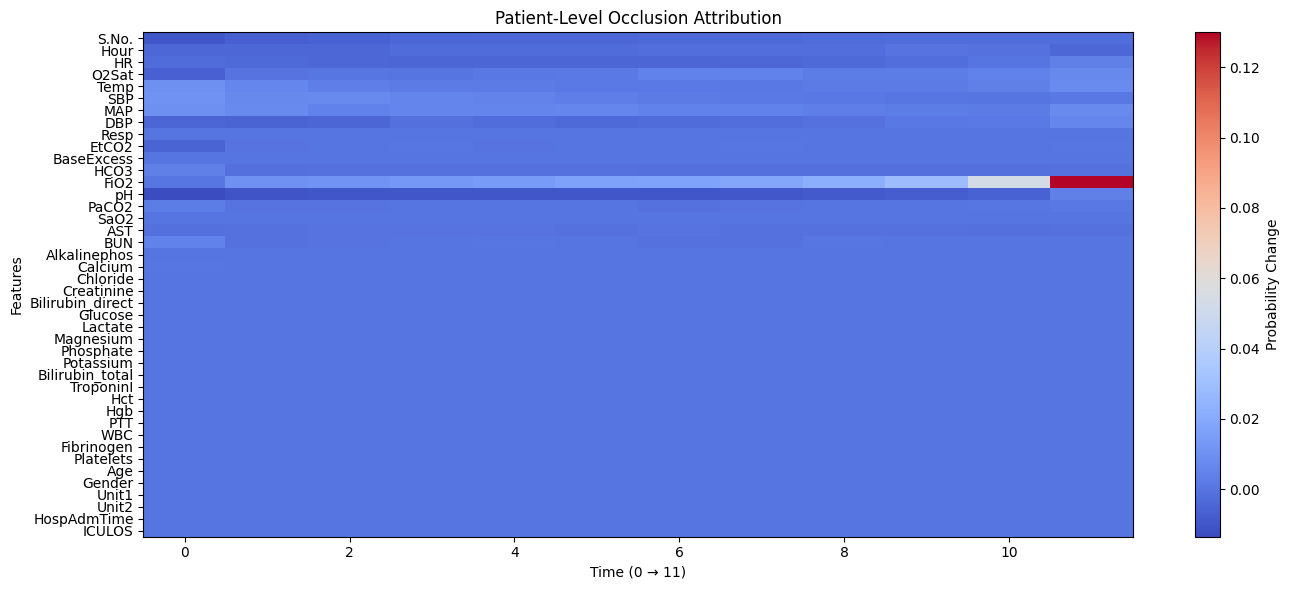

In [71]:
plt.figure(figsize=(14,6))
plt.imshow(attr_matrix.T, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Probability Change")
plt.xlabel("Time (0 → 11)")
plt.ylabel("Features")
plt.yticks(np.arange(len(feature_cols)), feature_cols)
plt.title("Patient-Level Occlusion Attribution")
plt.tight_layout()
plt.show()


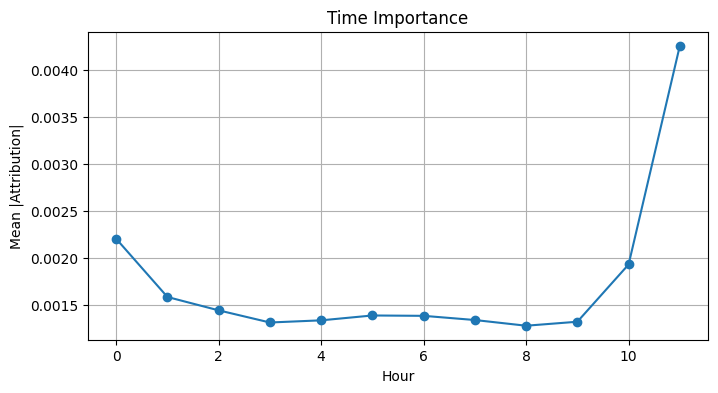

In [72]:
time_importance = np.mean(np.abs(attr_matrix), axis=1)

plt.figure(figsize=(8,4))
plt.plot(range(12), time_importance, marker="o")
plt.xlabel("Hour")
plt.ylabel("Mean |Attribution|")
plt.title("Time Importance")
plt.grid(True)
plt.show()


In [74]:
feature_importance = np.mean(np.abs(attr_matrix), axis=0)
top_idx = np.argsort(feature_importance)[-10:]

print("\nTop 10 Influential Features:")
for i in reversed(top_idx):
    print(f"{feature_cols[i]} : {feature_importance[i]:.6f}")



Top 10 Influential Features:
FiO2 : 0.027994
pH : 0.009220
MAP : 0.005401
S.No. : 0.004635
SBP : 0.003890
Temp : 0.003882
HR : 0.003795
DBP : 0.003185
O2Sat : 0.003127
Hour : 0.002846


In [75]:
print("Original probability:", y_prob[0][0])
print("Max occlusion impact:", np.max(np.abs(attr_matrix)))


Original probability: 0.9692335
Max occlusion impact: 0.13000082969665527


In [81]:
def model_predict_flat(X_flat):
    """
    X_flat shape: (n_samples, 12*42)
    convert back to (n_samples, 12, 42)
    """
    X_reshaped = X_flat.reshape(-1, 12, 42)
    return model.predict(X_reshaped)


In [129]:
import numpy as np

# Save full training data
np.save("X_train.npy", X_train)


In [82]:
background = X_train[:50].reshape(50, -1)


In [83]:
import shap

explainer = shap.KernelExplainer(model_predict_flat, background)


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/stepWARNING:tensorflow:5 out of the last 513 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001E25A94B400> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step


In [120]:
new_patient_flat = new_patient.reshape(1, -1)

shap_values = explainer.shap_values(
    new_patient_flat,
    nsamples=1000  # increase to 500 for more accuracy
)


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


100%|██████████| 1/1 [00:03<00:00,  3.20s/it]


In [121]:
shap_values = shap_values[0]


In [122]:
shap_values = shap_values.reshape(12, 42)


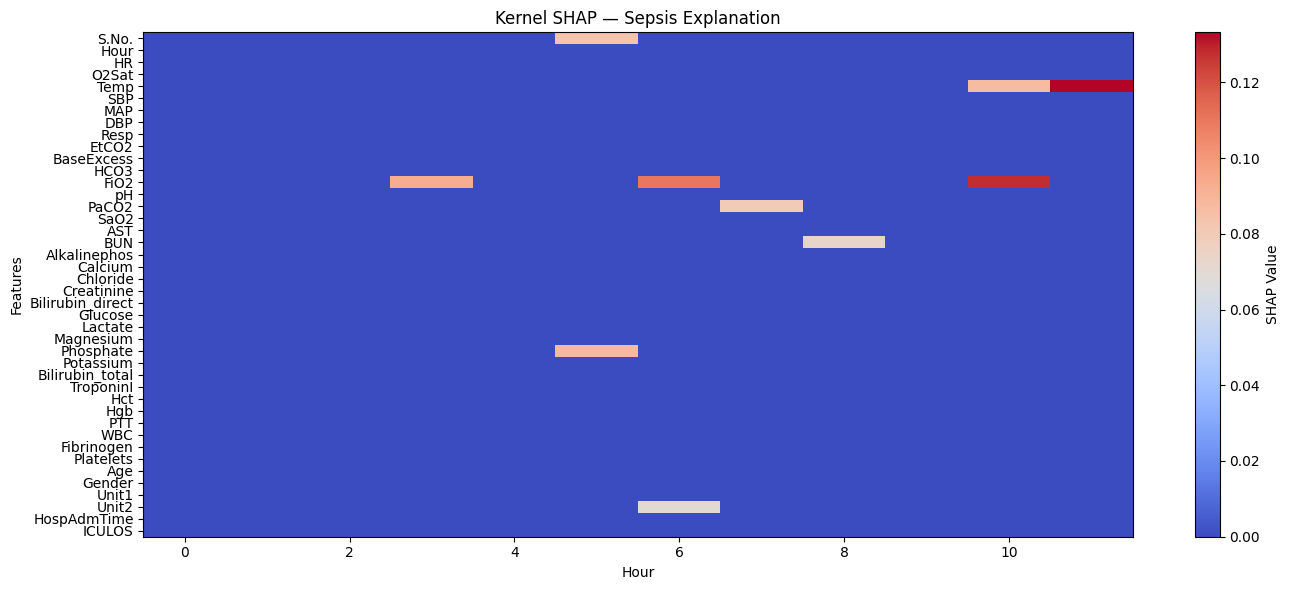

In [123]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14,6))
# plt.imshow(shap_values.T, aspect="auto", cmap="coolwarm")
# plt.colorbar(label="SHAP Value")
# plt.xlabel("Hour")
# plt.ylabel("Features")
# plt.title("Kernel SHAP — Sepsis Explanation")
# plt.show()

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,6))

plt.imshow(shap_values.T, aspect="auto", cmap="coolwarm")
plt.colorbar(label="SHAP Value")

plt.xlabel("Hour")
plt.ylabel("Features")

# 🔥 Add feature names here
plt.yticks(
    np.arange(len(feature_cols)),
    feature_cols
)

plt.title("Kernel SHAP — Sepsis Explanation")
plt.tight_layout()
plt.show()


In [124]:
feature_importance = np.mean(np.abs(shap_values), axis=0)
top_idx = np.argsort(feature_importance)[-10:]

print("Top Features:")
for i in reversed(top_idx):
    print(feature_cols[i], feature_importance[i])


Top Features:
FiO2 0.027537557385519967
Temp 0.018306509271735657
Phosphate 0.007304345457556601
S.No. 0.0069181815644282175
PaCO2 0.006604508327714633
BUN 0.006076265957671831
Unit2 0.005828547602680777
BaseExcess 0.0
AST 0.0
SaO2 0.0


In [133]:
import json

with open("feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
